<a href="https://colab.research.google.com/github/VuTuanAnh0949/RAG-LangChain-Ablation-Study/blob/main/%5BSolution%5D_RAG_Ablation_QueryTransform_HyDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Environment Setup


### 1.1 Install required packages

In [ ]:
!pip install -q \
  "langchain>=0.2.0" \
  "langchain-core>=0.2.0" \
  "langchain-community>=0.1.0" \
  "langchain-text-splitters>=0.2.0" \
  "chromadb>=0.5.0" \
  "langchain-chroma>=0.2.0" \
  "pypdf" \
  "ragas>=0.2.0" \
  "datasets>=2.14.0" \
  "pandas" \
  "matplotlib" \
  "seaborn" \
  "openai>=1.0.0" \
  "langchain-openai>=0.1.0" \
  "gdown" \
  "tiktoken" \
  "nest_asyncio"

### 1.2 Import libraries

In [ ]:
import os
import re
import json
import glob
import time
import gdown
import random
import asyncio
import unicodedata
import numpy as np
import pandas as pd
import seaborn as sns
import nest_asyncio
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

from tqdm import tqdm
from typing import List
from openai import OpenAI
from google.colab import userdata
from langchain_chroma import Chroma

from datasets import Dataset

from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

from ragas import evaluate
from ragas.run_config import RunConfig
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)
from ragas.embeddings import LangchainEmbeddingsWrapper

nest_asyncio.apply()

/tmp/ipython-input-3037808454.py:34: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/tmp/ipython-input-3037808454.py:34: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
/tmp/ipython-input-3037808454.py:34: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
/tmp/ipython-input-3037808454.py:34: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed

### 1.3 Set global seed for reproducibility (SEED = 42)

In [ ]:
SEED = 42

def set_global_seed(seed_value: int = 42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    print(f"Global seed set to {seed_value}")

set_global_seed(SEED)

Global seed set to 42


### 1.4 Configure API Keys

In [ ]:
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]

print("OpenAI API Key configured successfully")

OpenAI API Key configured successfully


### 1.5 Batch Processing Configuration

In [ ]:
BATCH_SIZE = 32
EMBEDDING_BATCH_SIZE = 100

LLM_MODEL = "gpt-4o-mini"
EMBEDDING_MODEL = "text-embedding-3-small"

EVAL_SAMPLE_SIZE = None
EVAL_MAX_WORKERS = 64
EVAL_TIMEOUT = 180

print(f"Configuration:")
print(f"  - LLM Model: {LLM_MODEL}")
print(f"  - Embedding Model: {EMBEDDING_MODEL}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - RAGAS Eval Workers: {EVAL_MAX_WORKERS}")
print(f"  - Eval Sample Size: {'ALL' if EVAL_SAMPLE_SIZE is None else EVAL_SAMPLE_SIZE}")

Configuration:
  - LLM Model: gpt-4o-mini
  - Embedding Model: text-embedding-3-small
  - Batch Size: 32
  - RAGAS Eval Workers: 64
  - Eval Sample Size: ALL


## 2. Data Preparation


### 2.1 Download data

In [ ]:
!gdown 1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW

Downloading...
From (original): https://drive.google.com/uc?id=1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW
From (redirected): https://drive.google.com/uc?id=1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW&confirm=t&uuid=beff5860-094f-4f4a-8b3a-faff85dcf778
To: /content/RAG_DATA.zip
100% 133M/133M [00:02<00:00, 59.1MB/s]


In [ ]:
file_id = "1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW"
zip_path = "/content/data.zip"
gdown.download(f"https://drive.google.com/uc?id={file_id}", zip_path, quiet=False)

!unzip -o /content/data.zip
DATA_DIR = "RAG_DATA"

Downloading...
From (original): https://drive.google.com/uc?id=1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW
From (redirected): https://drive.google.com/uc?id=1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW&confirm=t&uuid=2e3f30eb-89ea-4b67-99d1-b24b3bb1c2b0
To: /content/data.zip
100%|██████████| 133M/133M [00:02<00:00, 64.6MB/s]


Archive:  /content/data.zip
   creating: RAG_DATA/
  inflating: RAG_DATA/AI_Agents_Smolagents.pdf  
  inflating: RAG_DATA/AI_Image_Gen_Edit_CFM.pdf  
  inflating: RAG_DATA/AI_Linear_Algebra_NumPy_Practice.pdf  
  inflating: RAG_DATA/AI_Multi_Agent_Supervisor.pdf  
  inflating: RAG_DATA/AI_Problem_Solving.pdf  
  inflating: RAG_DATA/AI_Problem_Solving_Framework.pdf  
  inflating: RAG_DATA/AI_Vietnamese_Poetry.pdf  
  inflating: RAG_DATA/Applied_Statistics_AI.pdf  
  inflating: RAG_DATA/CNN_Exercise.pdf  
  inflating: RAG_DATA/Effective_Data_Presentation.pdf  
  inflating: RAG_DATA/Emoji_Generation_Stable_Diffusion.pdf  
  inflating: RAG_DATA/Git_DS_Roadmap.pdf  
  inflating: RAG_DATA/Hand_Gesture_Control_System_Tutorial.pdf  
  inflating: RAG_DATA/Interpolation_Missing_Data.pdf  
  inflating: RAG_DATA/LangChain_RAG_PDF_QA_Guide.pdf  
  inflating: RAG_DATA/LLM_Alignment_DPO.pdf  
  inflating: RAG_DATA/LLM_IT_SAT_Reading.pdf  
  inflating: RAG_DATA/LLM_Math_Reasoning_GRPO.pdf  
  inflatin

### 2.2 Download testing file

In [ ]:
file_id = "1a5RL7ex88w_5tZ1g6R31QTrfibvxqT_Q"
gdown.download(f"https://drive.google.com/uc?id={file_id}", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1a5RL7ex88w_5tZ1g6R31QTrfibvxqT_Q
To: /content/testset.json
100%|██████████| 312k/312k [00:00<00:00, 20.3MB/s]


'testset.json'

## 3. Model Configuration (API-based)


In [ ]:
def get_llm(
    model_name: str = LLM_MODEL,
    temperature: float = 0.0,
    max_tokens: int = 8192,
    seed: int = SEED,
):
    llm = ChatOpenAI(
        model=model_name,
        temperature=temperature,
        max_tokens=max_tokens,
        seed=seed,
        api_key=OPENAI_API_KEY,
    )
    print(f"LLM initialized: {model_name} (seed={seed})")
    return llm


def get_embeddings(
    model_name: str = EMBEDDING_MODEL,
    chunk_size: int = EMBEDDING_BATCH_SIZE,
):
    embeddings = OpenAIEmbeddings(
        model=model_name,
        api_key=OPENAI_API_KEY,
        chunk_size=chunk_size,
    )
    print(f"Embeddings initialized: {model_name} (batch_size={chunk_size})")
    return embeddings

## 4. RAG Components


### 4.1 Define Vietnamese text cleaning function

In [ ]:
def clean_vietnamese_text(text: str) -> str:
    text = unicodedata.normalize('NFC', text)
    text = "".join(
        char for char in text
        if not unicodedata.category(char).startswith('C') or char in '\n\t'
    )
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\n\s*\n', '\n', text)
    return text.strip()

### 4.2 Define document loader and text splitter

In [ ]:
class SimpleLoader:
    def load_pdf(self, pdf_file: str):
        docs = PyPDFLoader(pdf_file, extract_images=True).load()
        for doc in docs:
            doc.page_content = clean_vietnamese_text(doc.page_content)
        return docs

    def load_dir(self, dir_path: str) -> List:
        pdf_files = glob.glob(f"{dir_path}/*.pdf")
        if not pdf_files:
            raise ValueError(f"No PDF files found in {dir_path}")

        all_docs = []
        for pdf_file in tqdm(pdf_files, desc="Loading PDFs"):
            try:
                all_docs.extend(self.load_pdf(pdf_file))
            except Exception as e:
                pass
        return all_docs


class TextSplitter:
    def __init__(
        self,
        chunk_size: int = 1024,
        chunk_overlap: int = 128,
    ):
        self.splitter = RecursiveCharacterTextSplitter(
            separators=["\n\n", "\n", " ", ""],
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            length_function=len,
        )

    def split(self, documents):
        return self.splitter.split_documents(documents)

### 4.3 Define vector database class (API Embeddings)

In [ ]:
class VectorDB:
    def __init__(
        self,
        documents=None,
        embedding=None,
        collection_name: str = "vietnamese_docs",
        persist_dir: str = "/content/chroma_data",
    ):
        self.persist_dir = persist_dir
        self.collection_name = collection_name
        self.embedding = embedding or get_embeddings()
        self.db = self._build_db(documents)

    def _build_db(self, documents):
        if documents is None or len(documents) == 0:
            db = Chroma(
                collection_name=self.collection_name,
                embedding_function=self.embedding,
                persist_directory=self.persist_dir,
            )
        else:
            print(f"Building vector database with {len(documents)} documents...")
            db = Chroma.from_documents(
                documents=documents,
                embedding=self.embedding,
                collection_name=self.collection_name,
                persist_directory=self.persist_dir,
            )
            print(f"Vector database built successfully!")
        return db

    def get_retriever(self, search_kwargs: dict = None):
        if search_kwargs is None:
            search_kwargs = {"k": 3}

        return self.db.as_retriever(
            search_type="similarity",
            search_kwargs=search_kwargs,
        )

    def similarity_search(self, query: str, k: int = 3):
        """Direct similarity search for HyDE"""
        return self.db.similarity_search(query, k=k)

### 4.4* Define HyDE (Hypothetical Document Embedding) Transformer (Ablation Study)

In [ ]:
class HyDEQueryTransformer:
    """HyDE - Tạo Hypothetical Document từ câu hỏi để cải thiện retrieval

    Ý tưởng: Thay vì sử dụng câu hỏi để search, ta tạo một "tài liệu giả định"
    trả lời câu hỏi đó. Tài liệu giả định này có đặc trưng embedding gần với
    tài liệu thực tế hơn là câu hỏi, giúp cải thiện recall trong retrieval.

    Reference: https://arxiv.org/abs/2212.10496
    """

    def __init__(self, llm):
        self.llm = llm
        self.prompt = PromptTemplate.from_template("""Hãy viết một đoạn văn ngắn (khoảng 100-150 từ) trả lời câu hỏi sau.
Viết như thể đây là một đoạn trích từ tài liệu chuyên ngành hoặc sách giáo khoa.
Đoạn văn nên chứa các thông tin, thuật ngữ kỹ thuật liên quan đến chủ đề.
Không cần bắt đầu bằng "Theo tài liệu" hay các cụm từ tương tự.

Câu hỏi: {question}

Đoạn văn:""")

    def generate_hypothetical_doc(self, question: str) -> str:
        """Tạo hypothetical document từ câu hỏi"""
        response = self.llm.invoke(self.prompt.format(question=question))
        return response.content.strip()

### 4.5* Define RAG pipeline with HyDE

In [ ]:
class FocusedAnswerParser(StrOutputParser):
    def parse(self, text: str) -> str:
        text = (text or "").strip()
        if "[TRẢ LỜI]:" in text:
            answer = text.split("[TRẢ LỜI]:")[-1].strip()
        else:
            answer = text

        answer = re.sub(r'^\s*[•\-\*]\s*', '', answer, flags=re.MULTILINE)
        answer = re.sub(r'\n+', ' ', answer).strip()
        return answer


class HyDEBatchRAG:
    """RAG với HyDE - Sử dụng Hypothetical Document để cải thiện retrieval"""

    def __init__(self, llm, vector_db, batch_size: int = BATCH_SIZE):
        self.llm = llm
        self.vector_db = vector_db
        self.batch_size = batch_size
        self.hyde_transformer = HyDEQueryTransformer(llm)
        self.prompt_template = """Bạn là trợ lý AI phân tích tài liệu tiếng Việt.

[TÀI LIỆU]:
{context}

[CÂU HỎI]:
{question}

Hãy trả lời dựa trên tài liệu. Nếu tài liệu không có thông tin, nói rõ "Không có thông tin".
[TRẢ LỜI]:"""
        self.prompt = PromptTemplate.from_template(self.prompt_template)
        self.answer_parser = FocusedAnswerParser()

    def _format_docs(self, docs):
        formatted = []
        seen = set()
        for doc in docs:
            content = (doc.page_content or "").strip()
            if content and len(content) > 40 and content not in seen:
                formatted.append(content)
                seen.add(content)
        return "\n\n".join(formatted)

    def hyde_retrieve(self, question: str, k: int = 3) -> dict:
        """Tạo hypothetical document và sử dụng nó để retrieve"""
        # Tạo hypothetical document
        hypothetical_doc = self.hyde_transformer.generate_hypothetical_doc(question)

        # Sử dụng hypothetical document để retrieve
        docs = self.vector_db.similarity_search(hypothetical_doc, k=k)

        return {
            "question": question,
            "hypothetical_doc": hypothetical_doc,
            "docs": docs,
            "contexts": [doc.page_content for doc in docs],
            "formatted_context": self._format_docs(docs)
        }

    def batch_retrieve(self, questions: List[str], k: int = 3) -> List[dict]:
        all_data = []
        for question in tqdm(questions, desc="HyDE Retrieving"):
            data = self.hyde_retrieve(question, k=k)
            all_data.append(data)
        return all_data

    def batch_generate(self, prompts: List[str]) -> List[str]:
        from langchain_core.messages import HumanMessage

        all_answers = []
        for i in tqdm(range(0, len(prompts), self.batch_size), desc="Generating answers"):
            batch = prompts[i:i + self.batch_size]

            messages_batch = [[HumanMessage(content=p)] for p in batch]
            batch_results = self.llm.batch(messages_batch)

            for result in batch_results:
                answer = self.answer_parser.parse(result.content)
                all_answers.append(answer)

        return all_answers

    def answer_with_contexts_batch(self, questions: List[str], k: int = 3):
        print(f"Processing {len(questions)} questions with HyDE...")
        print(f"Batch size: {self.batch_size}")

        retrieved_data = self.batch_retrieve(questions, k=k)

        prompts = [
            self.prompt.format(
                context=data["formatted_context"],
                question=data["question"]
            )
            for data in retrieved_data
        ]
        answers = self.batch_generate(prompts)

        results = []
        for data, answer in zip(retrieved_data, answers):
            results.append({
                "answer": answer,
                "contexts": data["contexts"],
                "hypothetical_doc": data["hypothetical_doc"]
            })

        return results

## 5. RAG System Initialization


In [ ]:
  set_global_seed(SEED)

llm = get_llm(model_name=LLM_MODEL, seed=SEED)
embeddings = get_embeddings(model_name=EMBEDDING_MODEL, chunk_size=EMBEDDING_BATCH_SIZE)

loader = SimpleLoader()
text_splitter = TextSplitter(chunk_size=1024, chunk_overlap=128)

raw_docs = loader.load_dir(DATA_DIR)
split_docs = text_splitter.split(raw_docs)
print(f"Total documents: {len(raw_docs)}, Split chunks: {len(split_docs)}")

vdb = VectorDB(documents=split_docs, embedding=embeddings)

# Sử dụng HyDEBatchRAG thay vì BatchRAG
rag = HyDEBatchRAG(llm, vector_db=vdb, batch_size=BATCH_SIZE)

print("\n" + "="*50)
print("RAG System with HyDE initialized!")
print(f"  - LLM: {LLM_MODEL} (API)")
print(f"  - Embeddings: {EMBEDDING_MODEL} (API)")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Seed: {SEED}")
print(f"  - Ablation: HyDE (Hypothetical Document Embedding)")
print("="*50)

Global seed set to 42
LLM initialized: gpt-4o-mini (seed=42)
Embeddings initialized: text-embedding-3-small (batch_size=100)


Loading PDFs: 100%|██████████| 45/45 [01:22<00:00,  1.83s/it]


Total documents: 1372, Split chunks: 2184
Building vector database with 2184 documents...
Vector database built successfully!

RAG System with HyDE initialized!
  - LLM: gpt-4o-mini (API)
  - Embeddings: text-embedding-3-small (API)
  - Batch Size: 32
  - Seed: 42
  - Ablation: HyDE (Hypothetical Document Embedding)


## 6. Evaluation


### 6.1 Load testing data from JSON

In [ ]:
testset_path = 'testset.json'

with open(testset_path, 'r', encoding='utf-8') as f:
    testset_data = json.load(f)

test_df = pd.DataFrame([
    {
        'user_input': item['user_input'],
        'reference': item['reference'],
        'reference_contexts': item['reference_contexts']
    }
    for item in testset_data
])

print(f"Loaded {len(test_df)} test questions from testset.json")
display(test_df.head())

Loaded 52 test questions from testset.json


,user_input,reference,reference_contexts
0,Máy học là gì và nó có vai trò gì trong phân l...,Máy học là một lĩnh vực phổ biến trong phân lo...,[I. Giới thiệu** **Text Classification (Tạm dị...
1,Cơ sở dữ liệu Vector là gì và nó được sử dụng ...,Cơ sở dữ liệu Vector được sử dụng trong việc x...,[II.2. Cài đặt và Import thư viện . . . . . . ...
2,What is the significance of the FA Cup in the ...,The FA Cup is mentioned in a spam message that...,[. . . . . . . . . . . . . . . . . . . 14 III....
3,What libraries are commonly used in AI VIET NA...,"In AI VIET NAM, commonly used libraries for na...",[Text FA to 87121 to receive entr...| |spam|Fr...
4,What are the key steps involved in the data pr...,The key steps involved in the data preprocessi...,"[phần đặc trưng và nhãn, sau khi có dataframe,..."


### 6.2* Run batch predictions with HyDE

In [ ]:
set_global_seed(SEED)

print(f"Starting HyDE RAG inference...")
print(f"LLM: {LLM_MODEL}")
print(f"Batch size: {BATCH_SIZE}")

questions = test_df['user_input'].tolist()

start_time = time.time()
batch_results = rag.answer_with_contexts_batch(questions, k=3)
elapsed_time = time.time() - start_time

print(f"Inference completed in {elapsed_time:.2f} seconds")
print(f"Average time per question: {elapsed_time/len(questions):.2f} seconds")

results = []
for idx, (result, (_, row)) in enumerate(zip(batch_results, test_df.iterrows())):
    results.append({
        "user_input": row['user_input'],
        "response": result["answer"],
        "retrieved_contexts": result["contexts"],
        "reference": row.get('reference', ''),
        "reference_contexts": row.get('reference_contexts', []),
        "hypothetical_doc": result.get("hypothetical_doc", "")
    })

eval_df = pd.DataFrame(results)
print(f"Collected {len(eval_df)} predictions")
display(eval_df.head())

Global seed set to 42
Starting HyDE RAG inference...
LLM: gpt-4o-mini
Batch size: 32
Processing 52 questions with HyDE...
Batch size: 32


Generating answers: 100%|██████████| 2/2 [00:51<00:00, 25.54s/it]

Inference completed in 285.84 seconds
Average time per question: 5.50 seconds
Collected 52 predictions


,user_input,response,retrieved_contexts,reference,reference_contexts,hypothetical_doc
0,Máy học là gì và nó có vai trò gì trong phân l...,Máy học (Machine Learning) là một lĩnh vực ngh...,[để giải quyết bài toán này: • Naive Bayes Cla...,Máy học là một lĩnh vực phổ biến trong phân lo...,[I. Giới thiệu** **Text Classification (Tạm dị...,Máy học (Machine Learning) là một nhánh của tr...
1,Cơ sở dữ liệu Vector là gì và nó được sử dụng ...,Cơ sở dữ liệu Vector là một hệ thống lưu trữ c...,[AI VIET NAM (AIO2025) aivietnam.edu.vn III. X...,Cơ sở dữ liệu Vector được sử dụng trong việc x...,[II.2. Cài đặt và Import thư viện . . . . . . ...,Cơ sở dữ liệu Vector là một hệ thống lưu trữ v...
2,What is the significance of the FA Cup in the ...,Không có thông tin.,[AI VIET NAM (AIO2025) aivietnam.edu.vn II. Xâ...,The FA Cup is mentioned in a spam message that...,[. . . . . . . . . . . . . . . . . . . 14 III....,"FA Cup, một trong những giải đấu bóng đá lâu đ..."
3,What libraries are commonly used in AI VIET NA...,Các thư viện thường được sử dụng trong AI VIET...,[cho hiệu suất cao và có thể xử lý lượng dữ li...,"In AI VIET NAM, commonly used libraries for na...",[Text FA to 87121 to receive entr...| |spam|Fr...,"Trong lĩnh vực trí tuệ nhân tạo tại Việt Nam, ..."
4,What are the key steps involved in the data pr...,Không có thông tin.,[Thu thập dữ liệu cho AI cần phải đa dạng và c...,The key steps involved in the data preprocessi...,"[phần đặc trưng và nhãn, sau khi có dataframe,...",Data preprocessing is a critical phase in the ...


### 6.2.1* View HyDE Examples

In [ ]:
# Xem ví dụ về hypothetical documents được tạo
print("=" * 50)
print("HyDE Examples - Hypothetical Documents")
print("=" * 50)

for i in range(min(3, len(eval_df))):
    print(f"\n--- Example {i+1} ---")
    print(f"Question: {eval_df.iloc[i]['user_input'][:100]}...")
    print(f"\nHypothetical Doc: {eval_df.iloc[i]['hypothetical_doc'][:200]}...")
    print("-" * 30)

HyDE Examples - Hypothetical Documents

--- Example 1 ---
Question: Máy học là gì và nó có vai trò gì trong phân loại văn bản?...

Hypothetical Doc: Máy học (Machine Learning) là một nhánh của trí tuệ nhân tạo (AI) tập trung vào việc phát triển các thuật toán cho phép máy tính học hỏi từ dữ liệu mà không cần lập trình cụ thể. Trong lĩnh vực phân l...
------------------------------

--- Example 2 ---
Question: Cơ sở dữ liệu Vector là gì và nó được sử dụng như thế nào trong việc phân loại tin nhắn Spam?...

Hypothetical Doc: Cơ sở dữ liệu Vector là một hệ thống lưu trữ và truy xuất thông tin dựa trên các vector trong không gian nhiều chiều, cho phép biểu diễn và xử lý dữ liệu phức tạp một cách hiệu quả. Trong lĩnh vực phâ...
------------------------------

--- Example 3 ---
Question: What is the significance of the FA Cup in the context of spam messages?...

Hypothetical Doc: FA Cup, một trong những giải đấu bóng đá lâu đời nhất thế giới, không chỉ thu hút sự chú ý của người hâm mộ mà cò

### 6.3 Evaluate RAG with RAGAS metrics

In [ ]:
if EVAL_SAMPLE_SIZE is not None:
    eval_subset = eval_df.sample(n=min(EVAL_SAMPLE_SIZE, len(eval_df)), random_state=SEED)
    print(f"Quick evaluation mode: Using {len(eval_subset)} samples")
else:
    eval_subset = eval_df
    print(f"Full evaluation: Using all {len(eval_subset)} samples")

eval_dataset = Dataset.from_pandas(eval_subset.reset_index(drop=True))

wrapped_embeddings = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(model='text-embedding-3-small')
)

run_config = RunConfig(
    max_workers=EVAL_MAX_WORKERS,
    timeout=EVAL_TIMEOUT,
    max_retries=1,
    max_wait=60,
)

print(f"Running RAGAS evaluation...")
print(f"   - Parallel workers: {EVAL_MAX_WORKERS}")
print(f"   - Samples: {len(eval_subset)}")

start_time = time.time()

ragas_results = evaluate(
    dataset=eval_dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall
    ],
    embeddings=wrapped_embeddings,
    run_config=run_config,
    raise_exceptions=False,
)

eval_time = time.time() - start_time
print(f"\nEvaluation completed in {eval_time:.1f} seconds")
print(f"  Average: {eval_time/len(eval_subset):.2f}s per sample")

print("=" * 50)
print("=== RAGAS SCORES (HyDE) ===")
print("=" * 50)
print(ragas_results)

Full evaluation: Using all 52 samples
Running RAGAS evaluation...
   - Parallel workers: 64
   - Samples: 52


/tmp/ipython-input-226048979.py:10: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  wrapped_embeddings = LangchainEmbeddingsWrapper(


Evaluating:   0%|          | 0/208 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[100]: InstructorRetryException(<failed_attempts>

<generation number="1">
<exception>
    The output is incomplete due to a max_tokens length limit.
</exception>
<completion>
    ChatCompletion(id='chatcmpl-CsZKO2IwuzGldeQF8RWN68tC5K02q', choices=[Choice(finish_reason='length', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n    "statements": [\n        {\n            "statement": "Việc điều chỉnh Adapter-tuning và kỹ thuật LoRA giúp tối ưu hóa tài nguyên trong quá trình fine-tuning các mô hình ngôn ngữ lớn.",\n            "reason": "The context discusses how LoRA and PEFT techniques optimize resource usage during fine-tuning of large language models.",\n            "verdict": 1\n        },\n        {\n            "statement": "Adapter-tuning và kỹ thuật LoRA giúp tối ưu hóa tài nguyên thông qua nhiều cách.",\n            "reason": "The context mentions that LoRA and related techniques optimize resources, implying multiple 


Evaluation completed in 1703.5 seconds
  Average: 32.76s per sample
=== RAGAS SCORES (HyDE) ===
{'faithfulness': 0.8071, 'answer_relevancy': 0.4967, 'context_precision': 0.8045, 'context_recall': 0.6321}


### 6.4 Visualize evaluation results

PDF saved: RAGAS_Evaluation_Report_HyDE.pdf


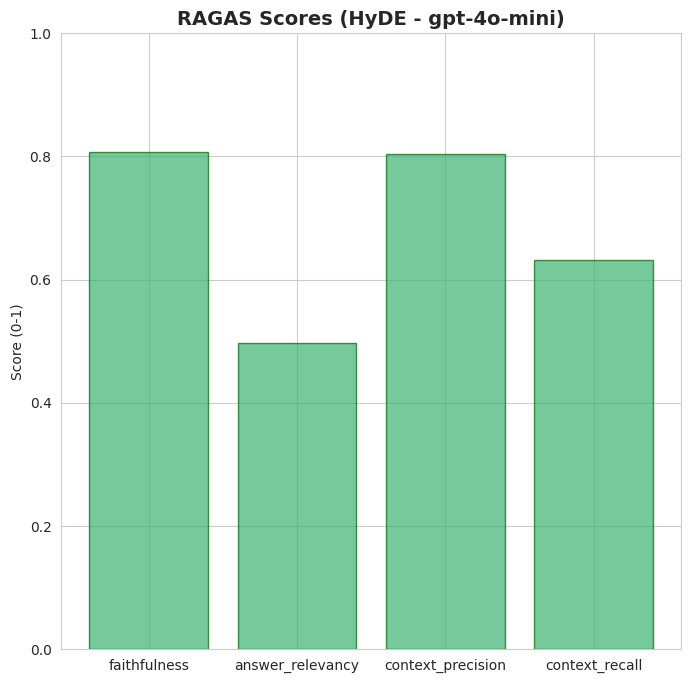

In [ ]:
results_df = ragas_results.to_pandas()
pdf_filename = "RAGAS_Evaluation_Report_HyDE.pdf"

with PdfPages(pdf_filename) as pdf:
    sns.set_style("whitegrid")
    fig = plt.figure(figsize=(8, 8))

    metric_cols = [col for col in ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
                   if col in results_df.columns]

    if metric_cols:
        scores = {col: results_df[col].mean() for col in metric_cols}
        plt.bar(scores.keys(), scores.values(), color='mediumseagreen', edgecolor='darkgreen', alpha=0.7)
        plt.title(f"RAGAS Scores (HyDE - {LLM_MODEL})", fontsize=14, fontweight='bold')
        plt.ylabel("Score (0-1)")
        plt.ylim(0, 1)
        pdf.savefig(fig)

print(f"PDF saved: {pdf_filename}")